In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('./heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape

(920, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [ ]:
# check the percentage of missing values in each column
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage.sort_values(ascending=False)


ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
exang        5.978261
thalch       5.978261
chol         3.260870
restecg      0.217391
cp           0.000000
dataset      0.000000
id           0.000000
age          0.000000
sex          0.000000
num          0.000000
dtype: float64

In [ ]:
# age column
df['age'].min(), df['age'].max()
print ("minimum age for heart disease is",df['age'].min())
print("maximum age for heart disease is",df['age'].max())

minimum age for heart disease is 28
maximum age for heart disease is 77


In [ ]:
# find the values of sex
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [ ]:
# check the percentage of missing values in each column
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage.sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
exang        5.978261
thalch       5.978261
chol         3.260870
restecg      0.217391
cp           0.000000
dataset      0.000000
id           0.000000
age          0.000000
sex          0.000000
num          0.000000
dtype: float64

In [ ]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [ ]:
# check the row of restecg where the missing vaues
df[df['restecg'].isnull()].head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
571,572,55,Male,Hungary,typical angina,140.0,295.0,False,NaN,136.0,False,0.0,NaN,NaN,NaN,1
598,599,34,Male,Switzerland,asymptomatic,115.0,0.0,NaN,NaN,154.0,False,0.2,upsloping,NaN,NaN,1


In [ ]:
# drop these rows of restecg where vales are NaN
df.dropna(subset=['restecg'], inplace=True)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

ca          609
thal        484
slope       308
fbs          89
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
cp            0
sex           0
dataset       0
id            0
age           0
restecg       0
num           0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        918 non-null    int64  
 1   age       918 non-null    int64  
 2   sex       918 non-null    object 
 3   dataset   918 non-null    object 
 4   cp        918 non-null    object 
 5   trestbps  859 non-null    float64
 6   chol      888 non-null    float64
 7   fbs       829 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    863 non-null    float64
 10  exang     863 non-null    object 
 11  oldpeak   856 non-null    float64
 12  slope     610 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       918 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 121.9+ KB


In [ ]:
# impute the missing values of slop with the help of mode of slop column
mode_slope = df['slope'].mode()[0]
df['slope'].fillna(mode_slope, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\3838765184.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['slope'].fillna(mode_slope, inplace=True)


ca          609
thal        484
fbs          89
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
cp            0
age           0
sex           0
dataset       0
id            0
restecg       0
slope         0
num           0
dtype: int64

In [ ]:
mode_slope = df['fbs'].mode()[0]
df['fbs'].fillna(mode_slope, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\1591109225.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fbs'].fillna(mode_slope, inplace=True)
C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\1591109225.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'].fillna(mode_slope, 

ca          609
thal        484
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
id            0
fbs           0
cp            0
sex           0
dataset       0
age           0
restecg       0
slope         0
num           0
dtype: int64

In [ ]:
# impute the missing values of oldpeak with the help of mean of oldpeak column
mean_oldpeak = df['oldpeak'].mean()
df['oldpeak'].fillna(mean_oldpeak, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\1265765390.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(mean_oldpeak, inplace=True)


ca          609
thal        484
trestbps     59
thalch       55
exang        55
chol         30
id            0
age           0
fbs           0
cp            0
sex           0
dataset       0
oldpeak       0
restecg       0
slope         0
num           0
dtype: int64

In [ ]:
mean_oldpeak = df['trestbps'].mean()
df['trestbps'].fillna(mean_oldpeak, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\2269832822.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trestbps'].fillna(mean_oldpeak, inplace=True)


ca          609
thal        484
exang        55
thalch       55
chol         30
id            0
sex           0
age           0
fbs           0
trestbps      0
cp            0
dataset       0
oldpeak       0
restecg       0
slope         0
num           0
dtype: int64

In [ ]:
# impute the missing values of thalch with the help of mean of thalach column
mean_thalach = df['thalch'].mean()
df['thalch'].fillna(mean_thalach, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\1376791110.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['thalch'].fillna(mean_thalach, inplace=True)


ca          609
thal        484
exang        55
chol         30
dataset       0
id            0
sex           0
age           0
fbs           0
trestbps      0
cp            0
restecg       0
oldpeak       0
thalch        0
slope         0
num           0
dtype: int64

In [ ]:
# drop the ca and thal columns because they have more than 50% missing values
df.drop(['ca', 'thal'], axis=1, inplace=True)
df.isnull().sum().sort_values(ascending=False)

exang       55
chol        30
sex          0
dataset      0
id           0
age          0
trestbps     0
cp           0
restecg      0
fbs          0
thalch       0
oldpeak      0
slope        0
num          0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        918 non-null    int64  
 1   age       918 non-null    int64  
 2   sex       918 non-null    object 
 3   dataset   918 non-null    object 
 4   cp        918 non-null    object 
 5   trestbps  918 non-null    float64
 6   chol      888 non-null    float64
 7   fbs       918 non-null    bool   
 8   restecg   918 non-null    object 
 9   thalch    918 non-null    float64
 10  exang     863 non-null    object 
 11  oldpeak   918 non-null    float64
 12  slope     918 non-null    object 
 13  num       918 non-null    int64  
dtypes: bool(1), float64(4), int64(3), object(6)
memory usage: 101.3+ KB


In [ ]:
# impute the missing values of exang with the help of mode of exang column
mode_exang = df['exang'].mode()[0]
df['exang'].fillna(mode_exang, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\1105347808.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['exang'].fillna(mode_exang, inplace=True)
C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\1105347808.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'].fillna(mode_exa

chol        30
id           0
sex          0
dataset      0
cp           0
age          0
trestbps     0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak      0
slope        0
num          0
dtype: int64

In [ ]:
# impute the missing values of chol with the help of mean of chol column
mean_chol = df['chol'].mean()
df['chol'].fillna(mean_chol, inplace=True)
df.isnull().sum().sort_values(ascending=False)

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\177460571.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['chol'].fillna(mean_chol, inplace=True)


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

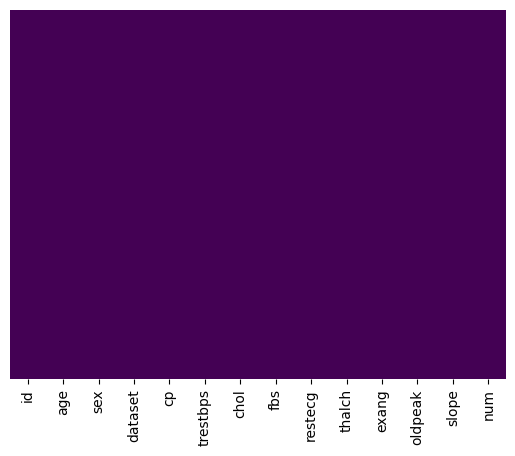

In [ ]:
# create the heatmap for check the missing values in the dataset
# plot the missing values using heatmap
import seaborn as sns
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\2313520943.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


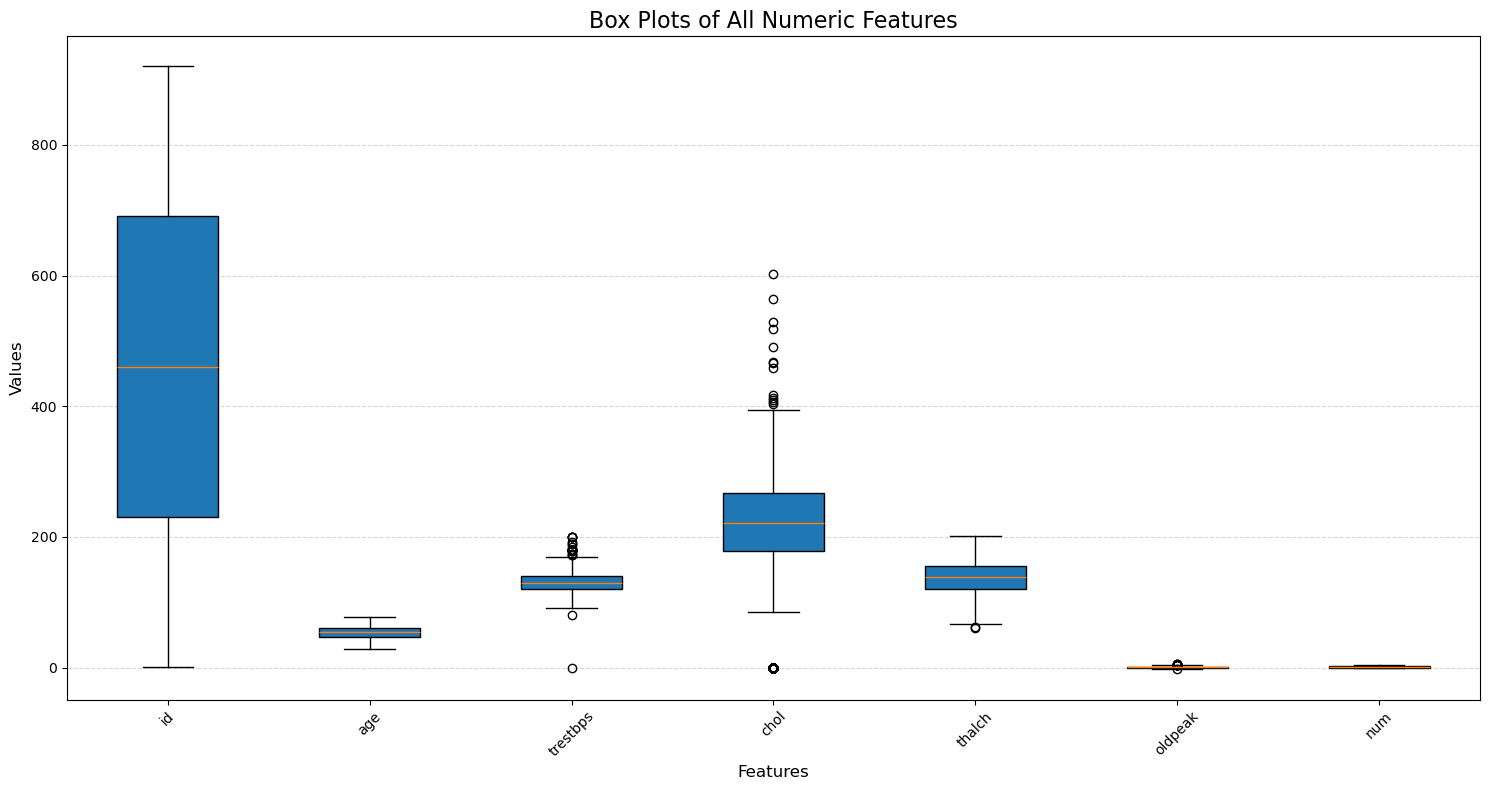

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Create one figure
plt.figure(figsize=(15, 8))

# Draw boxplots
plt.boxplot(
    [df[col].dropna() for col in numeric_cols],
    labels=numeric_cols,
    patch_artist=True
)

# Formatting
plt.title("Box Plots of All Numeric Features", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# print the row from df where trestbps values is 0
df[df['trestbps']==0]
# replace the value of trestbps column with mean value of trestbps column
df['trestbps'] = df['trestbps'].replace(0,df['trestbps'].mean())
df[df['trestbps']==0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num


C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\2313520943.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


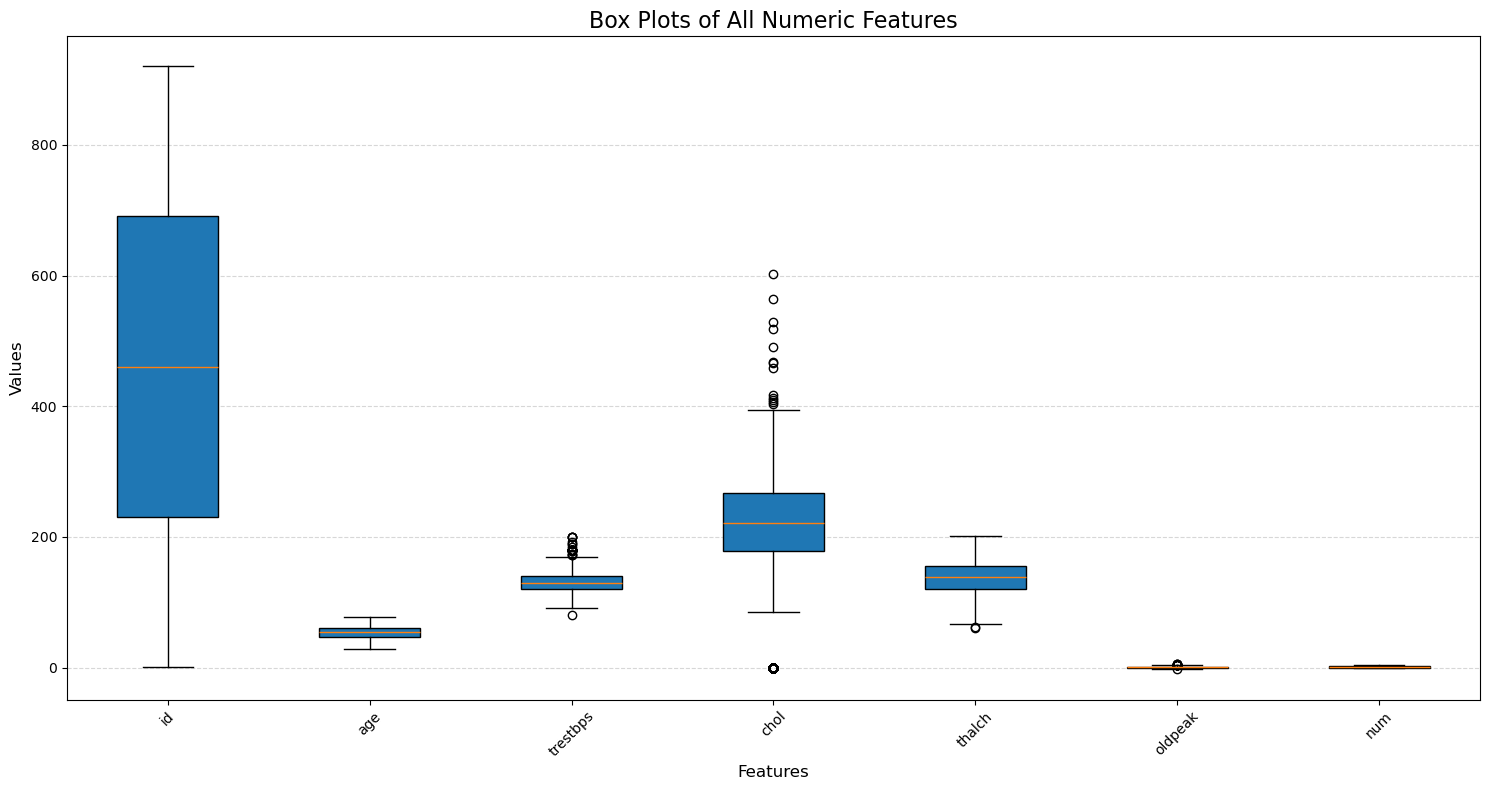

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Create one figure
plt.figure(figsize=(15, 8))

# Draw boxplots
plt.boxplot(
    [df[col].dropna() for col in numeric_cols],
    labels=numeric_cols,
    patch_artist=True
)

# Formatting
plt.title("Box Plots of All Numeric Features", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# print the row from df where chol values is 0
df[df['chol']==0]
# replace the value of chol column with mean value of chol column
df['chol'] = df['chol'].replace(0,df['chol'].mean())
df[df['chol']==0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num


C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_6652\2313520943.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


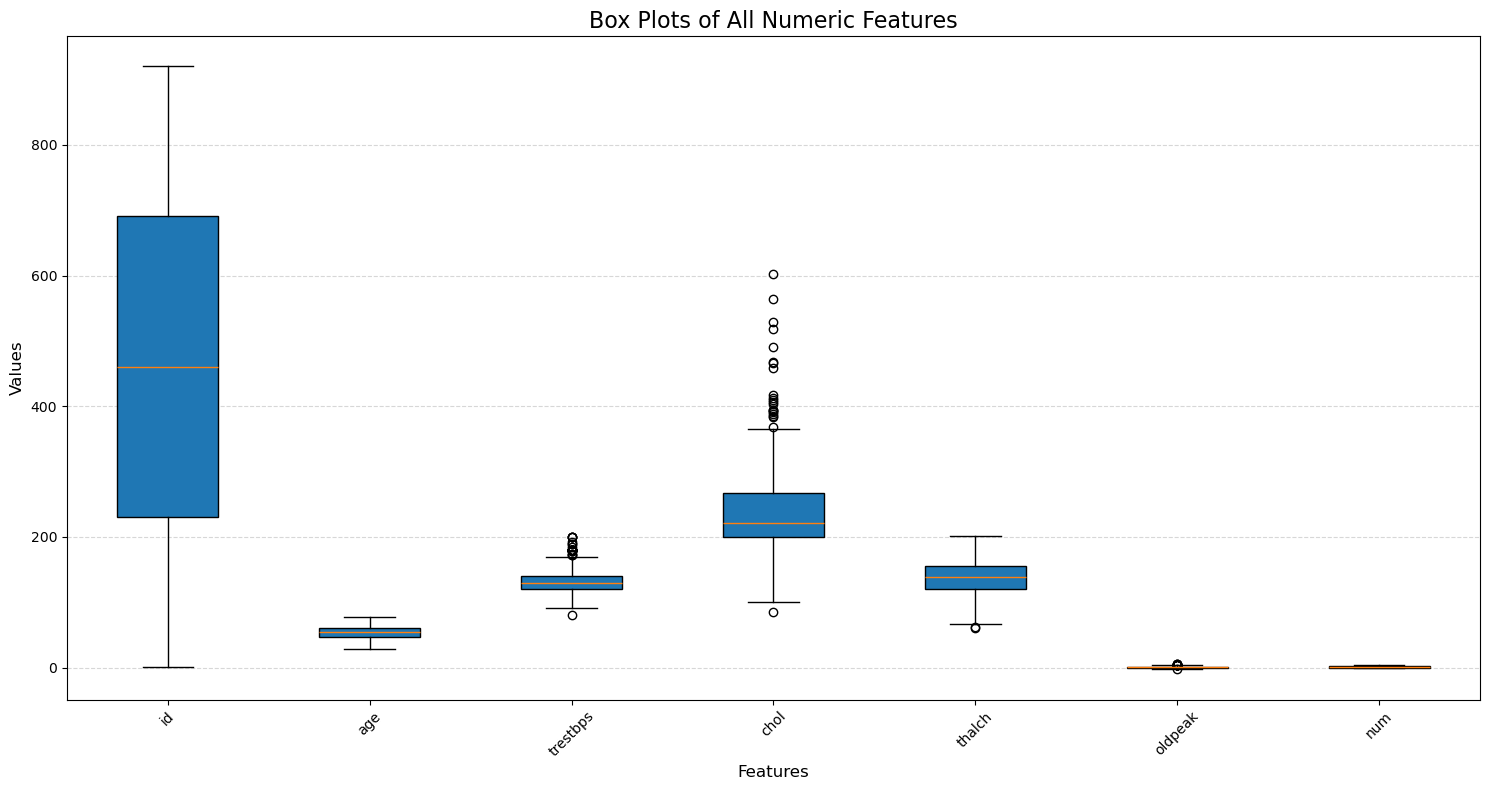

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Create one figure
plt.figure(figsize=(15, 8))

# Draw boxplots
plt.boxplot(
    [df[col].dropna() for col in numeric_cols],
    labels=numeric_cols,
    patch_artist=True
)

# Formatting
plt.title("Box Plots of All Numeric Features", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# lets make bins for age column for 0 to 12 are kids , 13 t0 19 are teeagers 20 to 40 are young 41 to 60 are adults and above 60 are seniors
bins = [0,12,19,40,60,100]
labels = ['kids','teenagers','young','adults','seniors']
df['age_bins'] = pd.cut(df['age'],bins=bins,labels=labels)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0,seniors
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2,seniors
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1,seniors
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0,young
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0,adults


In [ ]:
# drop the age column from the df because we have created the age_bins column
df.drop(['age'], axis=1, inplace=True)
df.head()

,id,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
0,1,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0,seniors
1,2,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2,seniors
2,3,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1,seniors
3,4,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0,young
4,5,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0,adults


In [ ]:
df.shape

(918, 14)

In [ ]:
df.tail()

,id,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
915,916,Female,VA Long Beach,asymptomatic,127.00000,333.0,True,st-t abnormality,154.000000,False,0.000000,flat,1,adults
916,917,Male,VA Long Beach,typical angina,132.14319,139.0,False,st-t abnormality,137.528389,False,0.880607,flat,0,seniors
917,918,Male,VA Long Beach,asymptomatic,122.00000,223.0,True,st-t abnormality,100.000000,False,0.000000,flat,2,adults
918,919,Male,VA Long Beach,asymptomatic,132.14319,385.0,True,lv hypertrophy,137.528389,False,0.880607,flat,0,adults
919,920,Male,VA Long Beach,atypical angina,120.00000,254.0,False,lv hypertrophy,93.000000,True,0.000000,flat,1,seniors


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        918 non-null    int64   
 1   sex       918 non-null    object  
 2   dataset   918 non-null    object  
 3   cp        918 non-null    object  
 4   trestbps  918 non-null    float64 
 5   chol      918 non-null    float64 
 6   fbs       918 non-null    bool    
 7   restecg   918 non-null    object  
 8   thalch    918 non-null    float64 
 9   exang     918 non-null    bool    
 10  oldpeak   918 non-null    float64 
 11  slope     918 non-null    object  
 12  num       918 non-null    int64   
 13  age_bins  918 non-null    category
dtypes: bool(2), category(1), float64(4), int64(2), object(5)
memory usage: 89.0+ KB


In [ ]:
df.head()


,id,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
0,1,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0,seniors
1,2,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2,seniors
2,3,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1,seniors
3,4,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0,young
4,5,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0,adults


In [ ]:
df.tail()

,id,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
915,916,Female,VA Long Beach,asymptomatic,127.00000,333.0,True,st-t abnormality,154.000000,False,0.000000,flat,1,adults
916,917,Male,VA Long Beach,typical angina,132.14319,139.0,False,st-t abnormality,137.528389,False,0.880607,flat,0,seniors
917,918,Male,VA Long Beach,asymptomatic,122.00000,223.0,True,st-t abnormality,100.000000,False,0.000000,flat,2,adults
918,919,Male,VA Long Beach,asymptomatic,132.14319,385.0,True,lv hypertrophy,137.528389,False,0.880607,flat,0,adults
919,920,Male,VA Long Beach,atypical angina,120.00000,254.0,False,lv hypertrophy,93.000000,True,0.000000,flat,1,seniors


In [ ]:
df.columns

Index(['id', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'num', 'age_bins'],
      dtype='object')

In [ ]:
df.describe()

,id,trestbps,chol,thalch,oldpeak,num
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,460.227669,132.287137,236.361188,137.528389,0.880607,0.995643
std,265.950093,17.929540,55.338694,25.159969,1.054284,1.143939
min,1.000000,80.000000,85.000000,60.000000,-2.600000,0.000000
25%,230.250000,120.000000,199.246622,120.000000,0.000000,0.000000
50%,459.500000,130.000000,221.000000,138.000000,0.800000,1.000000
75%,690.750000,140.000000,266.750000,156.000000,1.500000,2.000000
max,920.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [ ]:
df['id'].mode()

0        1
1        2
2        3
3        4
4        5
      ... 
913    916
914    917
915    918
916    919
917    920
Name: id, Length: 918, dtype: int64

In [ ]:
# convert all categorical columns to numerical columns using label encoding using loop
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'category':
        df[col] = le.fit_transform(df[col])

df.head()

,id,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
0,1,1,0,3,145.0,233.0,True,0,150.0,False,2.3,0,0,1
1,2,1,0,0,160.0,286.0,False,0,108.0,True,1.5,1,2,1
2,3,1,0,0,120.0,229.0,False,0,129.0,True,2.6,1,1,1
3,4,1,0,2,130.0,250.0,False,1,187.0,False,3.5,0,0,2
4,5,0,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0,0


In [ ]:
# split data into x and y
x = df.drop('num', axis=1)
y = df['num']
# split data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# print x and y
print(x_train.dtypes)
print(x_test.dtypes)

id            int64
sex           int64
dataset       int64
cp            int64
trestbps    float64
chol        float64
fbs            bool
restecg       int64
thalch      float64
exang          bool
oldpeak     float64
slope         int64
age_bins      int64
dtype: object
id            int64
sex           int64
dataset       int64
cp            int64
trestbps    float64
chol        float64
fbs            bool
restecg       int64
thalch      float64
exang          bool
oldpeak     float64
slope         int64
age_bins      int64
dtype: object


In [ ]:
# drop the id column from the df because it is not useful for our analysis
df.drop(['id'], axis=1, inplace=True)
df.head()

,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
0,1,0,3,145.0,233.0,True,0,150.0,False,2.3,0,0,1
1,1,0,0,160.0,286.0,False,0,108.0,True,1.5,1,2,1
2,1,0,0,120.0,229.0,False,0,129.0,True,2.6,1,1,1
3,1,0,2,130.0,250.0,False,1,187.0,False,3.5,0,0,2
4,0,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0,0


In [ ]:
# import the logistic regression model from sklearn
from sklearn.linear_model import LogisticRegression

In [ ]:
df.head()

,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,age_bins
0,1,0,3,145.0,233.0,True,0,150.0,False,2.3,0,0,1
1,1,0,0,160.0,286.0,False,0,108.0,True,1.5,1,2,1
2,1,0,0,120.0,229.0,False,0,129.0,True,2.6,1,1,1
3,1,0,2,130.0,250.0,False,1,187.0,False,3.5,0,0,2
4,0,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0,0


In [ ]:
# split data into x and y
x = df.drop('num', axis=1)
y = df['num']
# split data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# impliment the standard scaler to scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# train the model using logistic regression
model = LogisticRegression()
model.fit(x_train, y_train)

d:\Folder-for-Anaconda\envs\tensorflow\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# check the accuracy of the model
accuracy = model.score(x_test, y_test)
accuracy

0.5054347826086957

In [ ]:
# use the model to predict the values of y_test
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0])

In [ ]:
# Import required libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Reuse the already trained model and test data from the notebook
lr_model = model
X_test = x_test

# ==========================================
# Step 1: Predict on the Test Data
# ==========================================

# Make predictions
y_pred = lr_model.predict(X_test)

# ==========================================
# Step 2: Compare Actual vs Predicted
# ==========================================

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("First 20 Predictions:")
print(results.head(20))

# ==========================================
# Step 3: Calculate Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# ==========================================
# Step 4: Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ==========================================
# Step 5: Classification Report
# ==========================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# Step 6: Prediction Probabilities
# ==========================================

probabilities = lr_model.predict_proba(X_test)
class_labels = sorted(y.unique())
probability_columns = [f"Probability_Class_{label}" for label in class_labels]

prob_df = pd.DataFrame(
    probabilities,
    columns=probability_columns
)

print("\nPrediction Probabilities:")
print(prob_df.head())

# ==========================================
# Step 7: Combine Everything
# ==========================================

final_results = X_test.copy()
final_results["Actual"] = y_test.values
final_results["Predicted"] = y_pred

for i, label in enumerate(class_labels):
    final_results[f"Probability_Class_{label}"] = probabilities[:, i]

print("\nComplete Prediction Results:")
print(final_results.head())

# Optional: Save the results
final_results.to_csv("heart_disease_predictions.csv", index=False)

print("\nPrediction results saved as 'heart_disease_predictions.csv'")

First 20 Predictions:
     Actual  Predicted
670       3          1
30        0          0
377       0          0
535       1          0
809       1          0
795       1          1
363       0          0
584       1          1
165       0          0
483       0          0
775       2          1
551       1          1
770       1          1
696       1          0
720       2          1
312       0          0
715       1          1
309       0          0
848       0          1
618       3          0

Test Accuracy: 50.54%

Confusion Matrix:
[[62  9  0  0  0]
 [28 31  0  0  0]
 [ 7 20  0  0  0]
 [ 6 15  0  0  0]
 [ 1  5  0  0  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.87      0.71        71
           1       0.39      0.53      0.45        59
           2       0.00      0.00      0.00        27
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00         6

    accuracy

d:\Folder-for-Anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Folder-for-Anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Folder-for-Anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

In [ ]:
new_patient = pd.DataFrame(
    [[1, 0, 3, 145, 233, True, 0, 150, False, 2.3, 0, 4]],
    columns=x_train.columns      # or x.columns
)

prediction = lr_model.predict(new_patient)
probability = lr_model.predict_proba(new_patient)

print("Predicted Class:", prediction[0])

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

print(f"Probability of No Heart Disease: {probability[0][0]:.4f}")
print(f"Probability of Heart Disease: {probability[0][1]:.4f}")

Predicted Class: 0
No Heart Disease
Probability of No Heart Disease: 0.7246
Probability of Heart Disease: 0.0874
